In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import pandas as pd
fr_squid = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity': [45025,40924,35095,32254,34918,37628,39790,37838,37832,48124,52352,47252,34172,57125,61445,87579,77373,75387,87437,69569,81769,99348,100845,101101,87631,61176,75750,83846],
        'Price': [319.58,290.45,270.89,268.93,296.8,324.43,329.67,384.37,372.92,477.26,575.52,568.32,408.42,632.35,622.63,1010.57,1228.19,1378.08,1731.97,1275.25,1615.21,2575.29,2451.87,2506.99,2196.59,1998.9,2806.9,3593.75]}
df3=pd.DataFrame(fr_squid)


Dataset has 28 records and 3 columns


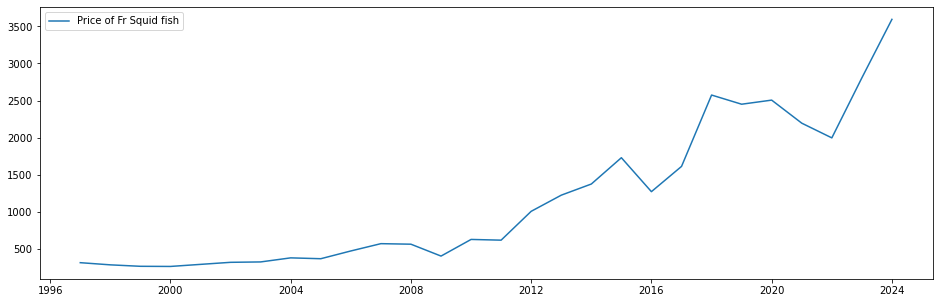

Results of Dickey-Fuller Test:
Test Statistic                  2.921997
p-value                         1.000000
#Lags Used                      4.000000
Number of Observations Used    23.000000
Critical Value (1%)            -3.752928
Critical Value (5%)            -2.998500
Critical Value (10%)           -2.638967
dtype: float64


In [88]:
# Check the dimensionality of the dataset
df3.shape
print("Dataset has {} records and {} columns".format(df3.shape[0], df3.shape[1]))
# Changing the YEAR data type and setting it as index
df3['YEAR'] = pd.Index(sm.tsa.datetools.dates_from_range('1996', '2023'))
df3.index = df3['YEAR']
# Check the data type
del df3['YEAR']
# View the dataset
df3.head()
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df3.index, df3['Price'], label = "Price of Fr Squid fish")
plt.legend(loc='best')
plt.show()
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df3test = adfuller(timeseries, autolag='AIC')
    df3output = pd.Series(df3test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df3test[4].items():
        df3output['Critical Value (%s)'%key] = value
    print (df3output)
# Call the function and run the test

adf_test(df3['Price'])


In [72]:
df3['Price_diff'] =df3['Price'].diff()
df3= df3.dropna()

In [73]:

#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df3test = adfuller(df3['Price_diff'],autolag='AIC')
df3output=pd.Series(df3test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df3test[4].items():
    df3output['critical value (%s)'%key]= value
print(df3output)

Results of Dickey-fuller test:
Test Statistic :                 -0.996603
p-value :                         0.754501
#lags used :                      6.000000
number of observations used :    20.000000
critical value (1%)              -3.809209
critical value (5%)              -3.021645
critical value (10%)             -2.650713
dtype: float64


In [74]:
df3['Price_diff_2'] =df3['Price_diff'].diff()
df3= df3.dropna()


In [75]:

#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df3test = adfuller(df3['Price_diff_2'],autolag='AIC')
df3output=pd.Series(df3test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df3test[4].items():
    df3output['critical value (%s)'%key]= value
print(df3output)

Results of Dickey-fuller test:
Test Statistic :                 -2.474829
p-value :                         0.121720
#lags used :                      9.000000
number of observations used :    16.000000
critical value (1%)              -3.924019
critical value (5%)              -3.068498
critical value (10%)             -2.673893
dtype: float64


In [76]:
df3['Price_diff_3'] =df3['Price_diff_2'].diff()
df3= df3.dropna()


In [77]:

#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df3test = adfuller(df3['Price_diff_3'],autolag='AIC')
df3output=pd.Series(df3test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df3test[4].items():
    df3output['critical value (%s)'%key]= value
print(df3output)

Results of Dickey-fuller test:
Test Statistic :                 -4.888748
p-value :                         0.000037
#lags used :                      6.000000
number of observations used :    18.000000
critical value (1%)              -3.859073
critical value (5%)              -3.042046
critical value (10%)             -2.660906
dtype: float64


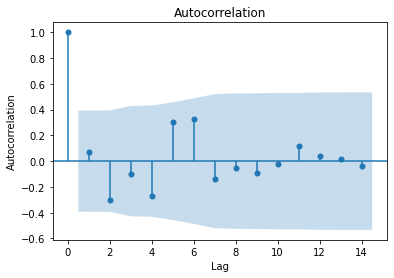

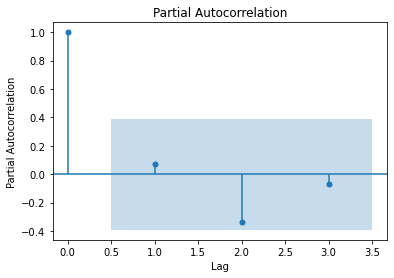

In [79]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df3['Price_diff'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=3)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

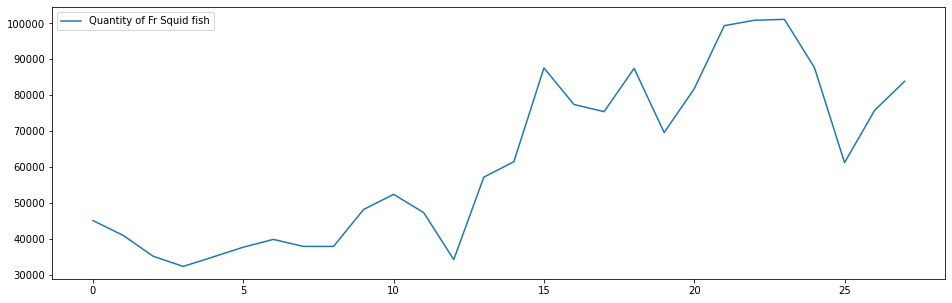

Results of Dickey-Fuller Test:
Test Statistic                 -1.260109
p-value                         0.647219
#Lags Used                      0.000000
Number of Observations Used    27.000000
Critical Value (1%)            -3.699608
Critical Value (5%)            -2.976430
Critical Value (10%)           -2.627601
dtype: float64


In [83]:
# for Quantity
# Check the dimensionality of the dataset
df3.shape
df3.head()
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df3.index, df3['Quantity'], label = "Quantity of Fr Squid fish")
plt.legend(loc='best')
plt.show()
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df3test = adfuller(timeseries, autolag='AIC')
    df3output = pd.Series(df3test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df3test[4].items():
        df3output['Critical Value (%s)'%key] = value
    print (df3output)
# Call the function and run the test

adf_test(df3['Quantity'])


In [84]:
df3['Quantity_diff']=df3['Quantity'].diff()
df3=df3.dropna()

In [85]:
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df3test = adfuller(timeseries, autolag='AIC')
    df3output = pd.Series(df3test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df3test[4].items():
        df3output['Critical Value (%s)'%key] = value
    print (df3output)
# Call the function and run the test

adf_test(df3['Quantity_diff'])

Results of Dickey-Fuller Test:
Test Statistic                 -5.425597
p-value                         0.000003
#Lags Used                      0.000000
Number of Observations Used    26.000000
Critical Value (1%)            -3.711212
Critical Value (5%)            -2.981247
Critical Value (10%)           -2.630095
dtype: float64


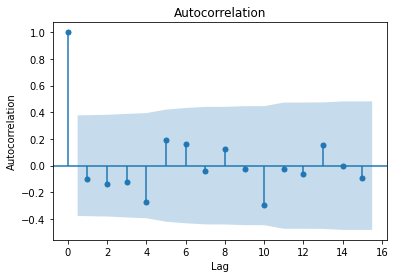

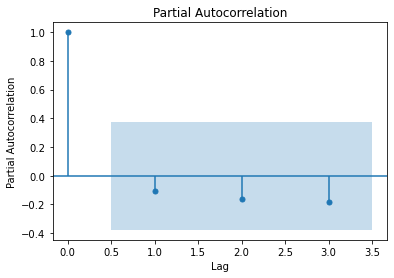

In [86]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df3['Quantity_diff'].values
#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=3)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

In [21]:
#2 nd objectieve
#Estimate the cointegrating relationship using OLS

# Add a constant column to the independent variable
variable1_with_constant = sm.add_constant(df3['Quantity'])

# Fit the OLS model
model = sm.OLS(df3['Price'], variable1_with_constant)
result = model.fit()

# Get the estimated coefficients
intercept = result.params[0]
slope = result.params[1]

# Print the results
print("Cointegrating Relationship:")
print("Price = {} + {} * Quantity".format(intercept, slope))
print("\nOLS Summary:")
print(result.summary())


Cointegrating Relationship:
Price = -970.0032019077454 + 0.03471875525239408 * Quantity

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     50.82
Date:                Sun, 16 Jul 2023   Prob (F-statistic):           2.92e-07
Time:                        21:12:17   Log-Likelihood:                -192.38
No. Observations:                  25   AIC:                             388.8
Df Residuals:                      23   BIC:                             391.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [24]:
#2 nd objectieve
#Estimate the cointegrating relationship using OLS

# Add a constant column to the independent variable
variable1_with_constant = sm.add_constant(df3['Quantity'])

# Fit the OLS model
model = sm.OLS(df3['Price_diff_2'], variable1_with_constant)
result = model.fit()

# Get the estimated coefficients
intercept = result.params[0]
slope = result.params[1]

# Print the results
print("Cointegrating Relationship:")
print("Price = {} + {} * Quantity".format(intercept, slope))
print("\nOLS Summary:")
print(result.summary())


Cointegrating Relationship:
Price = -35.218855524388886 + 0.0010480512072135611 * Quantity

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:           Price_diff_2   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.040
Method:                 Least Squares   F-statistic:                   0.07286
Date:                Sun, 16 Jul 2023   Prob (F-statistic):              0.790
Time:                        21:13:56   Log-Likelihood:                -186.71
No. Observations:                  25   AIC:                             377.4
Df Residuals:                      23   BIC:                             379.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

In [92]:
# 3rd obj VAR model
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

# Extract the variables of interest
variables = df3[['Quantity', 'Price']]

# Create a VAR model with a specified lag order (p)
model = VAR(variables)
results = model.fit(maxlags=1) 
parameters = results.params
print("Parameter Estimates:")
print(parameters)
print("\n")
print(model)
# Print the estimated coefficients
print("Estimated Coefficients:")
print(results.coefs)

# Forecast future values
n_periods = 10  # Number of periods to forecast
forecast = results.forecast(variables.values[-2:], steps=n_periods)  # Specify the appropriate lag order

# Print the forecasted values
print("Forecasted Values:")
print(forecast)



Parameter Estimates:
                 Quantity       Price
const        13325.908037  334.331234
L1.Quantity      0.724873   -0.008159
L1.Price         4.567454    1.265692


Estimated Coefficients:
[[[ 0.72487338  4.56745371]
  [-0.00815925  1.26569243]]]
Forecasted Values:
[[ 90517.92788049   4198.79269411]
 [ 98117.73526548   4910.15270723]
 [106875.73723258   5748.50694307]
 [117053.32385024   6738.14680326]
 [128950.91967231   7907.68498338]
 [142916.98162192   9290.8851158 ]
 [159358.31067331  10927.63842641]
 [178751.9873497   12865.11574595]
 [201659.28520651  15159.12821737]
 [228741.97131253  17875.73600911]]


In [2]:
import pandas as pd
fr_squid = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity': [45025,40924,35095,32254,34918,37628,39790,37838,37832,48124,52352,47252,34172,57125,61445,87579,77373,75387,87437,69569,81769,99348,100845,101101,87631,61176,75750,83846],
        'Price': [319.58,290.45,270.89,268.93,296.8,324.43,329.67,384.37,372.92,477.26,575.52,568.32,408.42,632.35,622.63,1010.57,1228.19,1378.08,1731.97,1275.25,1615.21,2575.29,2451.87,2506.99,2196.59,1998.9,2806.9,3593.75]}
df3=pd.DataFrame(fr_squid)

In [3]:
# Assuming you have a DataFrame 'data' containing the price and quantity variables.
# We'll use the ADF test to check for stationarity.
from statsmodels.tsa.stattools import adfuller
data=df3[['Price','Quantity']]
def are_series_stationary(data, threshold=0.05):
    result = adfuller(data)
    p_value = result[1]
    return p_value <= threshold

# Test for stationarity of price and quantity
is_price_stationary = are_series_stationary(df3['Price'])
is_quantity_stationary = are_series_stationary(df3['Quantity'])

# If both series are non-stationary, proceed with cointegration test
if not is_price_stationary and not is_quantity_stationary:
    result = coint_johansen(data, det_order=0, k_ar_diff=1)

    # Get the trace statistics and critical values for different significance levels (e.g., 90%, 95%, 99%)
    trace_statistic = result.lr1
    trace_critical_values = result.cvt[:, 1]  # Use 1% critical value (you can choose other values as well)

    # Find the number of cointegrated vectors (relationships)
    num_cointegrated_vectors = sum(trace_statistic > trace_critical_values)

    if num_cointegrated_vectors > 0:
        print("The variables price and quantity are cointegrated.")
    else:
        print("The variables price and quantity are not cointegrated.")
else:
    print("Both variables should be non-stationary for cointegration testing.")


The variables price and quantity are not cointegrated.


In [4]:
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# Extract the variables
variables = df3[[ 'Quantity','Price']]

# Perform Johansen cointegration test
coint_result = coint_johansen(variables, det_order=-1, k_ar_diff=1)

# Extract the cointegrating vectors
coint_vectors = coint_result.evec

# Specify the number of cointegrating vectors to use for prediction
num_coint_vectors = 1

# Create the VECM model using the cointegrating vectors
model = VECM(variables, k_ar_diff=1, coint_rank=num_coint_vectors, deterministic='nc')
model_fit = model.fit()
print(model)
# Generate predictions for the next 'n' steps
n = 10
forecast = model_fit.predict(steps=10)

# Print the forecasted values
print("Forecasted Values:")
print(forecast)
model_fit.predict(10, 0.05)

Forecasted Values:
[[85431.1426352   4077.02260714]
 [84932.00748996  4578.45220929]
 [84431.36955571  5157.37645302]
 [83850.34909379  5823.88171003]
 [83181.550839    6591.33833304]
 [82411.44716912  7475.03098325]
 [81524.70689741  8492.56462704]
 [80503.66403258  9664.21033695]
 [79327.97760826 11013.30938518]
 [77974.22585318 12566.73823016]]


(array([[85431.1426352 ,  4077.02260714],
        [84932.00748996,  4578.45220929],
        [84431.36955571,  5157.37645302],
        [83850.34909379,  5823.88171003],
        [83181.550839  ,  6591.33833304],
        [82411.44716912,  7475.03098325],
        [81524.70689741,  8492.56462704],
        [80503.66403258,  9664.21033695],
        [79327.97760826, 11013.30938518],
        [77974.22585318, 12566.73823016]]),
 array([[62065.95052828,  3459.20186108],
        [53063.66666652,  3629.25871586],
        [45881.68742015,  3911.5780207 ],
        [39645.6494753 ,  4282.54733997],
        [33994.70122992,  4740.94766545],
        [28731.28492549,  5292.14070261],
        [23729.67802456,  5945.27083785],
        [18900.27759208,  6712.38970498],
        [14173.1527479 ,  7608.25717595],
        [ 9489.3336155 ,  8650.42763887]]),
 array([[108796.33474212,   4694.84335319],
        [116800.3483134 ,   5527.64570272],
        [122981.05169126,   6403.17488534],
        [128055.04871228

In [5]:
coint_vectors

array([[ 1.21314767e-05, -4.32489727e-05],
       [-1.41507694e-03,  1.81718830e-03]])

In [6]:
vecm_res = model.fit()
vecm_res.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,-0.2798,0.319,-0.878,0.380,-0.904,0.345
L1.Price,10.4952,13.862,0.757,0.449,-16.674,37.665
,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,-0.0071,0.008,-0.840,0.401,-0.024,0.009
L1.Price,0.2690,0.367,0.734,0.463,-0.449,0.987
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,0.0131,0.028,0.463,0.643,-0.042,0.069
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,-0.0010,0.001,-1.308,0.191,-0.002,0.000
,coef,std err,z,P>|z|,[0.025,0.975]


lower bounds of confidence intervals:
[[63871.476  3297.284]
 [56919.416  3047.918]
 [50689.26   2769.941]
 [45088.991  2502.331]
 [39992.383  2254.901]]

point forecasts:
[[87332.959  3935.102]
 [88851.099  4083.489]
 [89510.536  4147.965]
 [89797.117  4175.983]
 [89921.649  4188.159]]

upper bounds of confidence intervals:
[[110794.442   4572.92 ]
 [120782.783   5119.06 ]
 [128331.811   5525.989]
 [134505.244   5849.636]
 [139850.914   6121.416]]


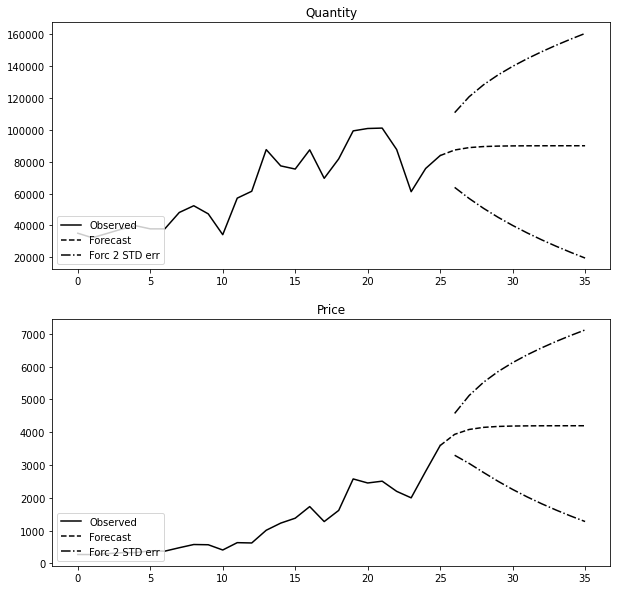

In [9]:
vecm_res.predict(steps=5)
forecast, lower, upper = vecm_res.predict(5, 0.05)
print("lower bounds of confidence intervals:")
print(lower.round(3))
print("\npoint forecasts:")
print(forecast.round(3))
print("\nupper bounds of confidence intervals:")
print(upper.round(3))
vecm_res.plot_forecast(steps=10)
